# Ray Calculation

Current step as of Fri Aug 7: Seems to be a units issue or some scale problem for the IAT. Gets bigger instead of smaller

In [1]:
import numpy as np
from astropy import units as u
import csv

In [2]:
from matplotlib import pyplot as plt

In [3]:
from radial_interpolation import *
from radial import sm

hello again


In [5]:
from interp_and_iat_2d import *

150 144 0.002 arcsec True


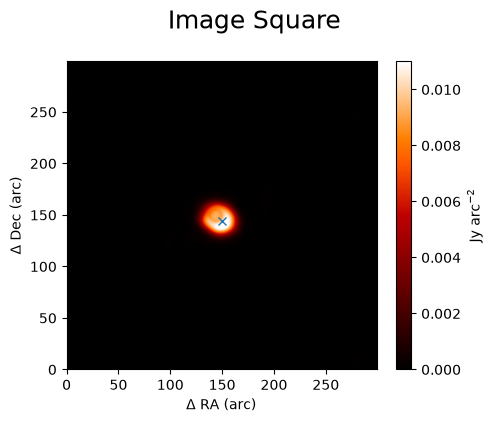

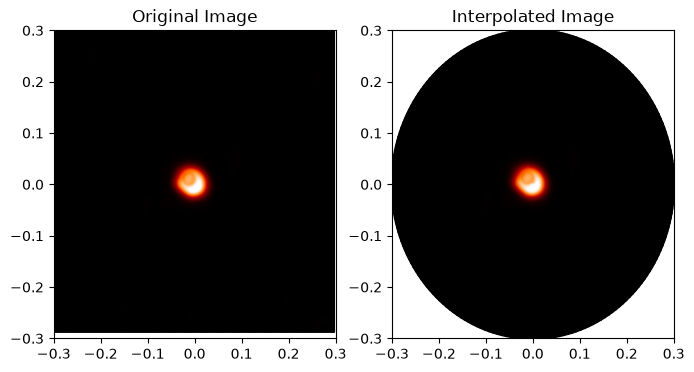

(201, 100)


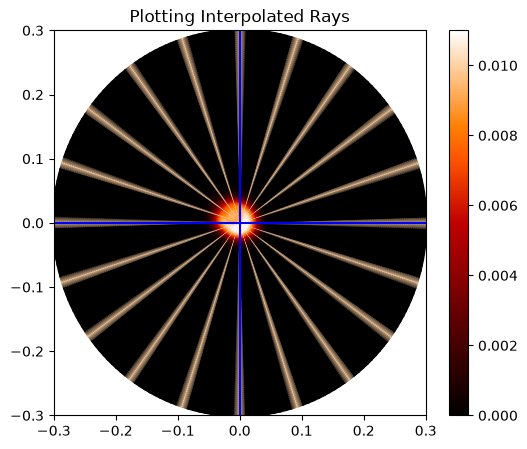

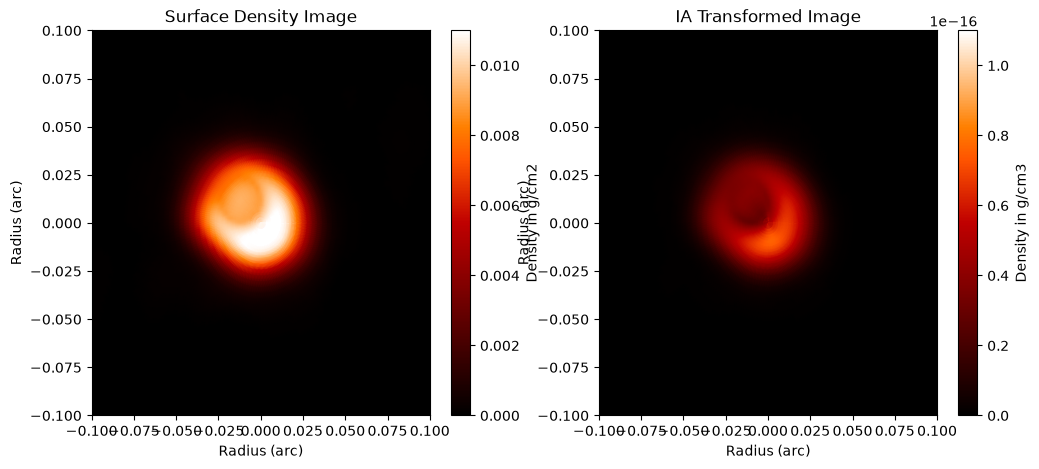

In [6]:
radius_2d_arc_hr,radius_2d_pc_hr,hr_abel = read_in_density_file("saved_data/hr_2d_density.csv",center_x=150,center_y=144,vmax_gcm2=0.011, vmax_gcm3=0.011e-14,
                                                                   pix_size_arcsec = 0.002 * u.arcsec,csm=False,rnge=0.1)

120
59 59 0.005 arcsec True


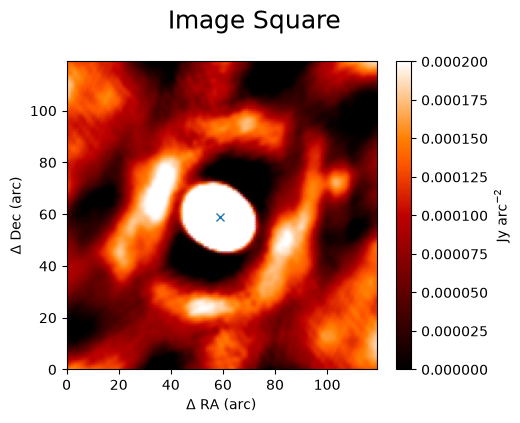

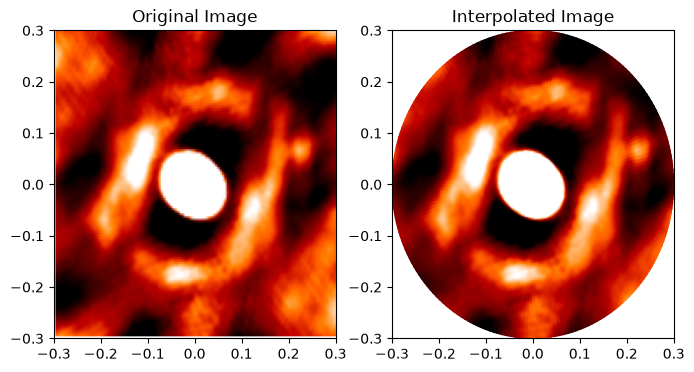

(201, 100)


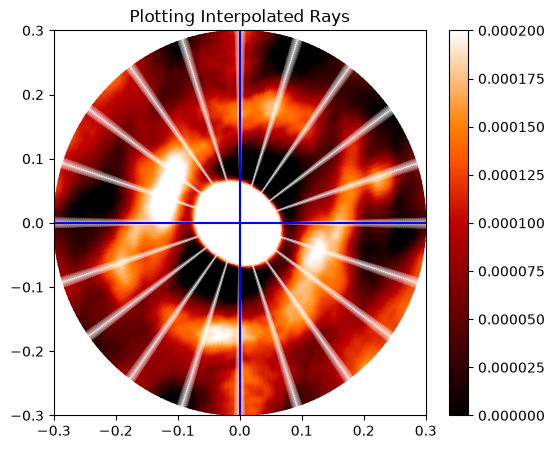

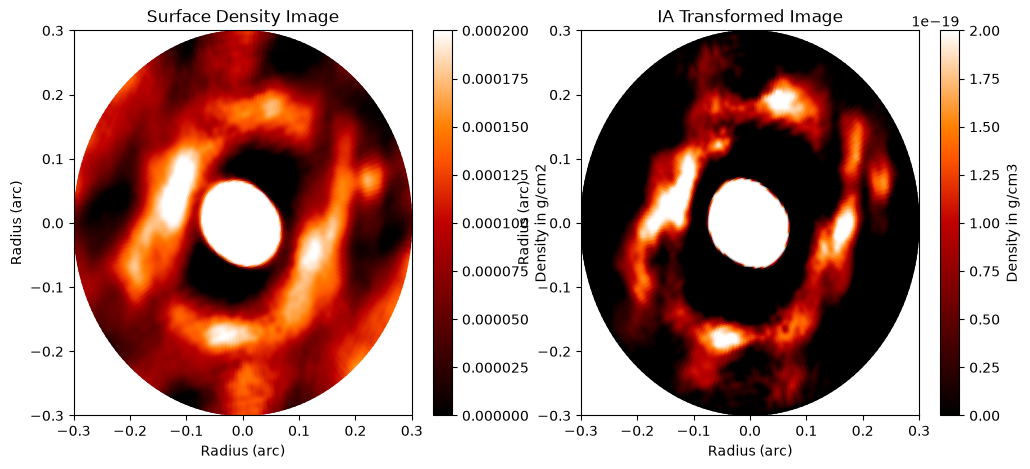

In [7]:
radius_2d_arc_lr,radius_2d_pc_lr,lr_abel = read_in_density_file("saved_data/lr_2d_density.csv",center_x=499,center_y=499,vmax_gcm2=0.0002, vmax_gcm3=2e-19,
                                                                   pix_size_arcsec = 0.005 * u.arcsec,csm=True)

120
59 59 0.005 arcsec True


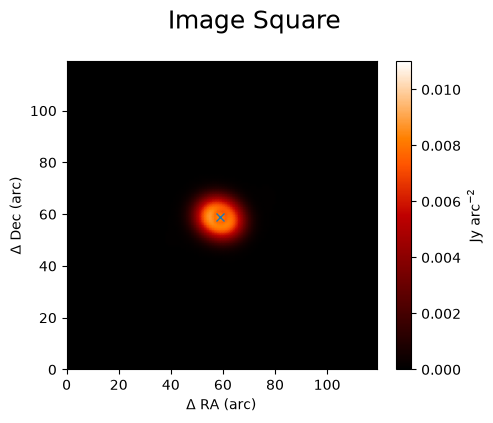

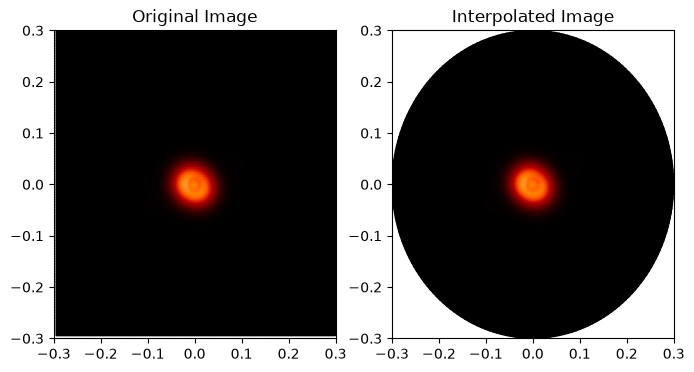

(201, 100)


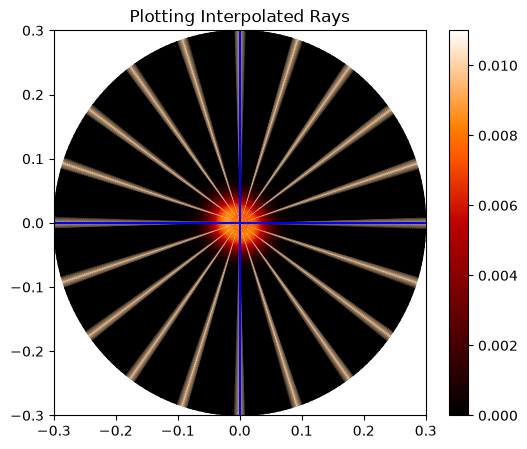

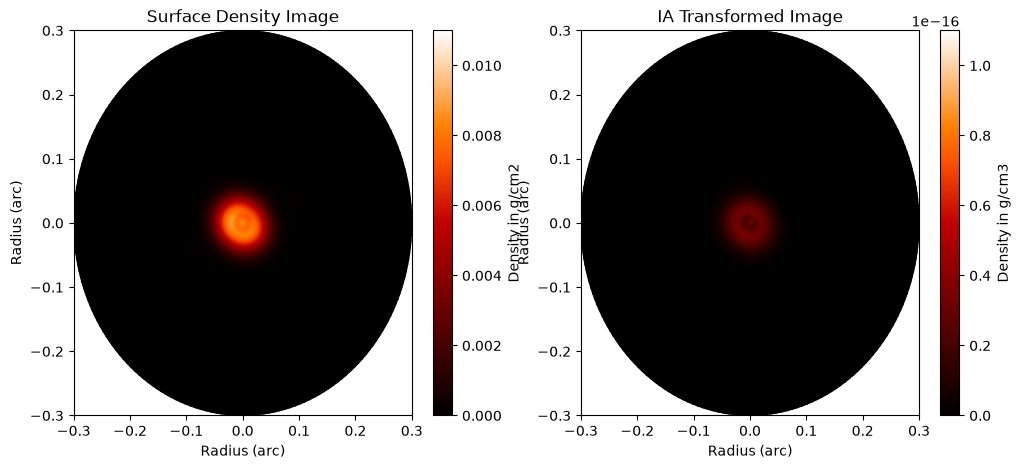

In [8]:
radius_2d_arc_reproj,radius_2d_pc_reproj,reproj_abel = read_in_density_file("saved_data/reproj_2d_density.csv",center_x=499,center_y=499,vmax_gcm2=0.011, vmax_gcm3=0.011e-14,
                                                                   pix_size_arcsec = 0.005 * u.arcsec,csm=True)

120
59 59 0.005 arcsec True


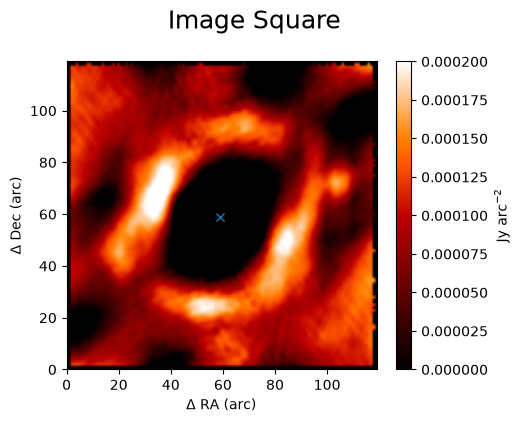

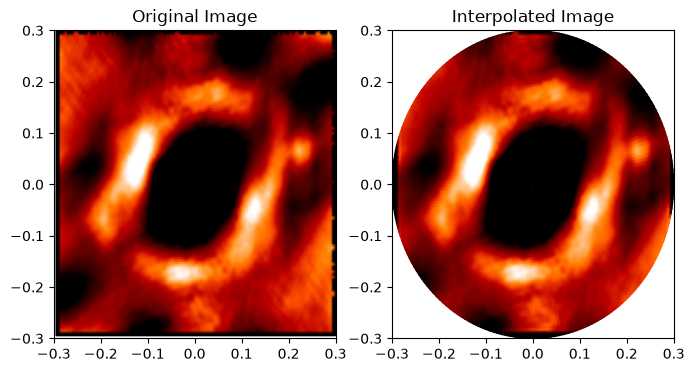

(201, 100)


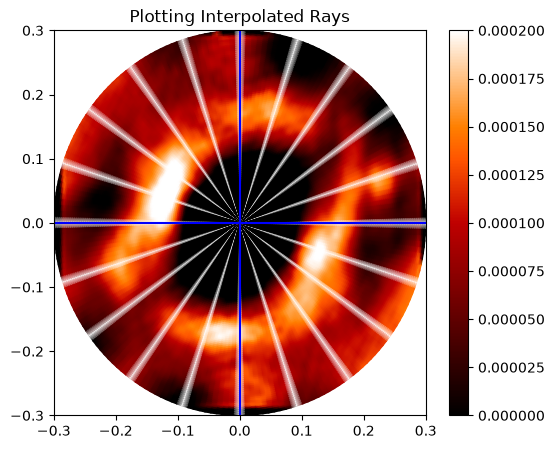

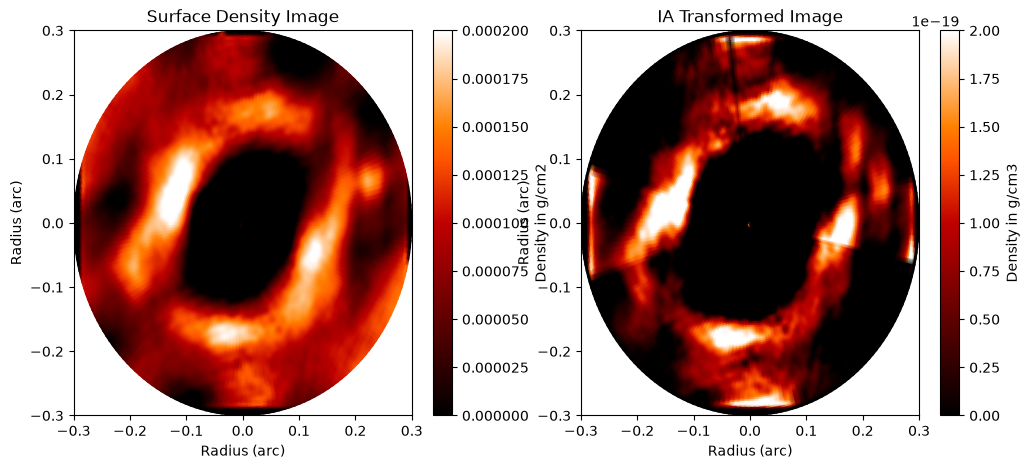

In [9]:
radius_2d_arc_csm,radius_2d_pc_csm,csm_abel = read_in_density_file("saved_data/csm_2d_density.csv",center_x=499,center_y=499,vmax_gcm2=0.0002, vmax_gcm3=2e-19,
                                                                   pix_size_arcsec = 0.005 * u.arcsec,csm=True)

In [10]:
x_grid_csm,y_grid_csm = get_grids()

/opt/anaconda3/envs/myenv/lib/python3.14/site-packages/astropy/units/quantity.py:676: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


(1e-20, 1e-12)

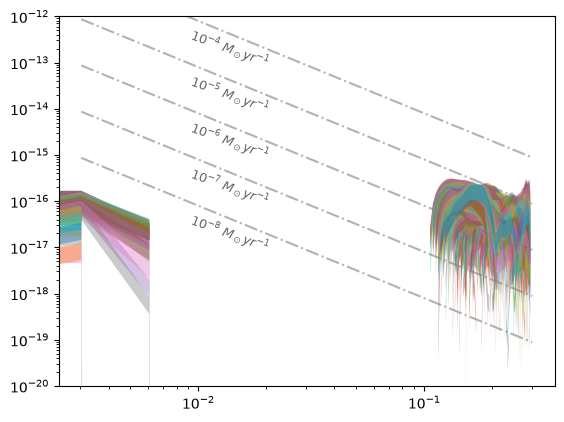

In [11]:
for i in range(radius_2d_arc_csm.shape[0]):
    #plt.plot(radius_2d_arc[i,], csm_abel[i,])
    plt.fill_between(radius_2d_arc_csm[i,],csm_abel[i,]+csm_abel[i,]*430,csm_abel[i,]+csm_abel[i,]*1000,alpha=0.4)

mdotexp = [-8,-7,-6,-5,-4]# msun/yr
v_yr = (1e6*u.cm/u.s).to(u.cm/u.yr)

for mdot in mdotexp:
    #print(mdot)

    rho_mdot = 10**mdot*u.M_sun/u.yr / (4*np.pi*radius_2d_pc_csm[0,].to(u.cm)**2*v_yr)
    plt.plot(radius_2d_arc_csm[0,], rho_mdot.to(u.g/u.cm**3).value, ls  = '-.',alpha = 0.6, c='grey')

    xtext = radius_2d_arc_csm[0,3]
    ytext = rho_mdot[35].to(u.g/u.cm**3)+rho_mdot[1].to(u.g/u.cm**3)/120

    #print(xtext,ytext)


    plt.text(xtext,ytext, f'$10^{{{mdot}}}$'+r' $M_\odot yr^{-1}$', fontsize=9, 
            rotation=-20, alpha = 0.6)

plt.semilogy()
plt.semilogx()
plt.ylim(10**-20,10**-12)

In [12]:
csm_abel_zero = np.zeros_like(csm_abel)
for i in range(radius_2d_arc_csm.shape[0]):
    for j in range(radius_2d_arc_csm.shape[1]):
        if radius_2d_arc_csm[i,j]>0.1:
            csm_abel_zero[i,j]=csm_abel[i,j]

In [13]:
from matplotlib.pyplot import cm

In [14]:
201/25

8.04

In [15]:
def plot_lines(rad,data,color):
    c=0
    for i in range(rad.shape[0]):
        #plt.plot(radius_2d_arc[i,], csm_abel[i,])
        if i%25==0:
            plt.fill_between(rad[i,],data[i,]+data[i,]*430,data[i,]+data[i,]*1000,color = color[i],alpha=.3)
            print(data[i,0])
            c+=1
    print(c," lines plotted")

-8.44321446458637e-20
-3.346514184689242e-20
-6.931888398283091e-20
-1.7739662640584239e-19
-3.938664512485421e-20
6.376548892488071e-20
-2.79034722210224e-20
-1.5418895499384821e-19
-8.443214464586378e-20
9  lines plotted
4.671833157759283e-17
4.7746457645302973e-17
5.970868821209864e-17
5.450187515423544e-17
5.0890315719546555e-17
4.3814431302920463e-17
4.7763183683464265e-17
4.6846946659601413e-17
4.671833157759283e-17
9  lines plotted
3.5542595132042393e-17
4.1899559724931185e-17
3.9560570791309466e-17
2.980978410874546e-17
2.4814970599639242e-17
2.931893238507989e-17
3.155718332726546e-17
3.049623207816032e-17
3.5542595132042393e-17
9  lines plotted
4.1337234982478175e-17
4.66800249894132e-17
4.1816513533098337e-17
3.20646181766184e-17
2.896423486696945e-17
3.313253828073426e-17
3.3608342250805344e-17
3.401274954456636e-17
4.1337234982478175e-17
9  lines plotted


Text(0.5, 1.0, 'Inverse Abel Transform for CSM Rays')

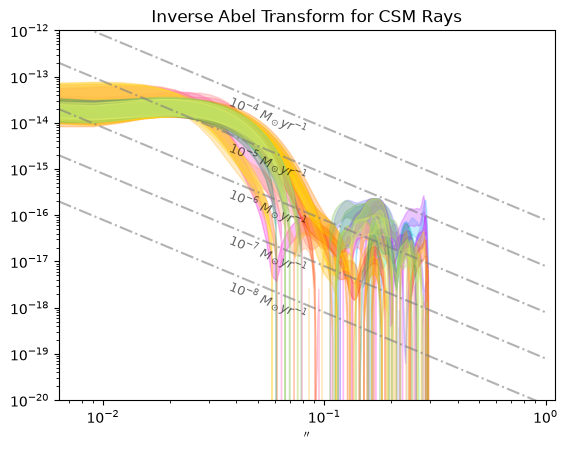

In [16]:
color = cm.cool(np.linspace(0, 1, 201))
plot_lines(radius_2d_arc_csm,csm_abel,color)

color = cm.spring(np.linspace(0, 1, 201))
plot_lines(radius_2d_arc_hr,hr_abel,color)

color = cm.autumn(np.linspace(0, 1, 201))
plot_lines(radius_2d_arc_reproj,reproj_abel,color)

color = cm.summer(np.linspace(0, 1, 201))
plot_lines(radius_2d_arc_lr,lr_abel,color)

mdotexp = [-8,-7,-6,-5,-4]# msun/yr
v_yr = (1e6*u.cm/u.s).to(u.cm/u.yr)

plt.ylim(10**-20,10**-12)
plt.xlim(1*10**-2.2,1.1)

x_range = np.linspace(1*10**-2.2,1,100)*u.arcsec
x_range_pc = sm(168,x_range).value*u.pc

for mdot in mdotexp:
    #print(mdot)

    rho_mdot = 10**mdot*u.M_sun/u.yr / (4*np.pi*x_range_pc.to(u.cm)**2*v_yr)
    plt.plot(x_range, rho_mdot.to(u.g/u.cm**3).value, ls  = '-.',alpha = 0.6, c='grey')

    xtext = x_range[3]
    ytext = rho_mdot[35].to(u.g/u.cm**3)+rho_mdot[1].to(u.g/u.cm**3)/65

    #print(xtext,ytext)


    plt.text(xtext,ytext, f'$10^{{{mdot}}}$'+r' $M_\odot yr^{-1}$', fontsize=9, 
            rotation=-22, alpha = 0.6)

plt.semilogy()
plt.semilogx()
plt.title("Inverse Abel Transform for CSM Rays")

4.671833157759283e-17
4.7746457645302973e-17
5.970868821209864e-17
5.450187515423544e-17
5.0890315719546555e-17
4.3814431302920463e-17
4.7763183683464265e-17
4.6846946659601413e-17
4.671833157759283e-17
9  lines plotted


Text(0.5, 1.0, 'Inverse Abel Transform for CSM Rays')

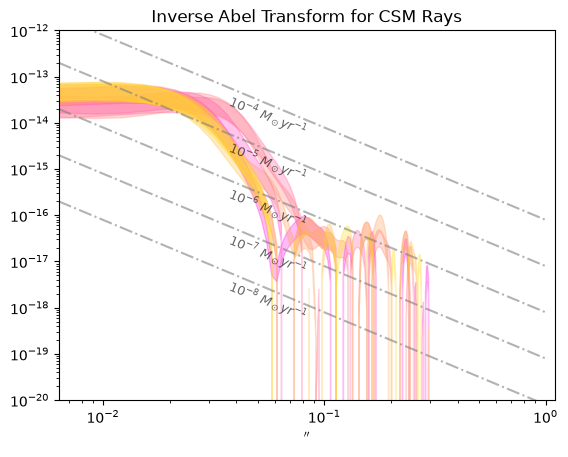

In [17]:
# color = cm.cool(np.linspace(0, 1, 201))
# plot_lines(radius_2d_arc_csm,csm_abel,color)

color = cm.spring(np.linspace(0, 1, 201))
plot_lines(radius_2d_arc_hr,hr_abel,color)

# color = cm.autumn(np.linspace(0, 1, 201))
# plot_lines(radius_2d_arc_reproj,reproj_abel,color)

# color = cm.summer(np.linspace(0, 1, 201))
# plot_lines(radius_2d_arc_lr,lr_abel,color)

mdotexp = [-8,-7,-6,-5,-4]# msun/yr
v_yr = (1e6*u.cm/u.s).to(u.cm/u.yr)

plt.ylim(10**-20,10**-12)
plt.xlim(1*10**-2.2,1.1)

x_range = np.linspace(1*10**-2.2,1,100)*u.arcsec
x_range_pc = sm(168,x_range).value*u.pc

for mdot in mdotexp:
    #print(mdot)

    rho_mdot = 10**mdot*u.M_sun/u.yr / (4*np.pi*x_range_pc.to(u.cm)**2*v_yr)
    plt.plot(x_range, rho_mdot.to(u.g/u.cm**3).value, ls  = '-.',alpha = 0.6, c='grey')

    xtext = x_range[3]
    ytext = rho_mdot[35].to(u.g/u.cm**3)+rho_mdot[1].to(u.g/u.cm**3)/65

    #print(xtext,ytext)


    plt.text(xtext,ytext, f'$10^{{{mdot}}}$'+r' $M_\odot yr^{-1}$', fontsize=9, 
            rotation=-22, alpha = 0.6)

plt.semilogy()
plt.semilogx()
plt.title("Inverse Abel Transform for CSM Rays")

lines shown:  9


Text(0.5, 1.0, 'Inverse Abel Transform for CSM Rays')

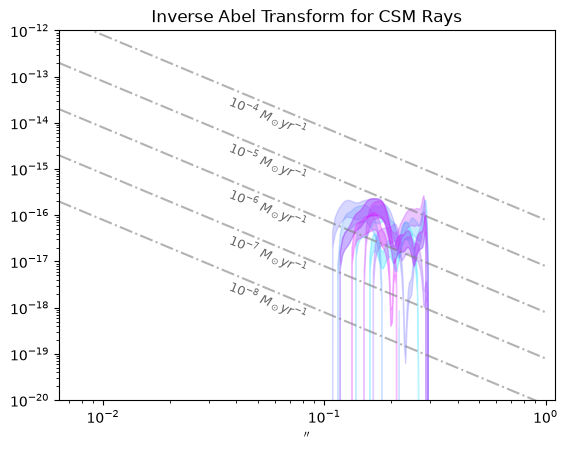

In [18]:
count=0
color = cm.cool(np.linspace(0, 1, 201))
for i in range(radius_2d_arc_csm.shape[0]):
    #plt.plot(radius_2d_arc[i,], csm_abel[i,])
    if i%25==0:
        count+=1
        plt.fill_between(radius_2d_arc_csm[i,],csm_abel[i,]+csm_abel[i,]*430,csm_abel[i,]+csm_abel[i,]*1000,color = color[i],alpha=.3)
print("lines shown: ", count)
mdotexp = [-8,-7,-6,-5,-4]# msun/yr
v_yr = (1e6*u.cm/u.s).to(u.cm/u.yr)

plt.ylim(10**-20,10**-12)
plt.xlim(1*10**-2.2,1.1)

x_range = np.linspace(1*10**-2.2,1,100)*u.arcsec
x_range_pc = sm(168,x_range).value*u.pc

for mdot in mdotexp:
    #print(mdot)

    rho_mdot = 10**mdot*u.M_sun/u.yr / (4*np.pi*x_range_pc.to(u.cm)**2*v_yr)
    plt.plot(x_range, rho_mdot.to(u.g/u.cm**3).value, ls  = '-.',alpha = 0.6, c='grey')

    xtext = x_range[3]
    ytext = rho_mdot[35].to(u.g/u.cm**3)+rho_mdot[1].to(u.g/u.cm**3)/65

    #print(xtext,ytext)


    plt.text(xtext,ytext, f'$10^{{{mdot}}}$'+r' $M_\odot yr^{-1}$', fontsize=9, 
            rotation=-22, alpha = 0.6)

plt.semilogy()
plt.semilogx()
plt.title("Inverse Abel Transform for CSM Rays")

lines shown:  21


Text(0.5, 1.0, 'Inverse Abel Transform for CSM Rays')

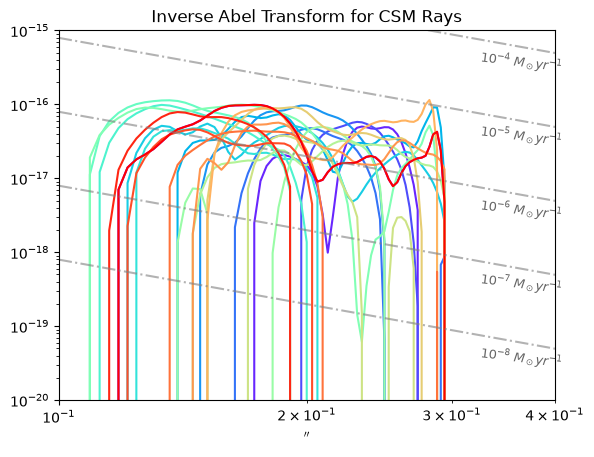

In [19]:
count=0
color = cm.rainbow(np.linspace(0, 1, 201))
for i in range(radius_2d_arc_csm.shape[0]):
    #plt.plot(radius_2d_arc[i,], csm_abel[i,])
    if i%10==0:
        count+=1
        plt.plot(radius_2d_arc_csm[i,],csm_abel[i,]+csm_abel[i,]*430,color = color[i],alpha=1)
print("lines shown: ", count)
mdotexp = [-8,-7,-6,-5,-4]# msun/yr
v_yr = (1e6*u.cm/u.s).to(u.cm/u.yr)

plt.ylim(10**-20,10**-15)
plt.xlim(1*10**-1,.4)

x_range = np.linspace(1*10**-1,1.1)*u.arcsec
x_range_pc = sm(168,x_range).value*u.pc

for mdot in mdotexp:
    #print(mdot)

    rho_mdot = 10**mdot*u.M_sun/u.yr / (4*np.pi*x_range_pc.to(u.cm)**2*v_yr)
    plt.plot(x_range, rho_mdot.to(u.g/u.cm**3).value, ls  = '-.',alpha = 0.6, c='grey')

    xtext = x_range[11]
    ytext = rho_mdot[35].to(u.g/u.cm**3)+rho_mdot[1].to(u.g/u.cm**3)/35

    #print(xtext,ytext)


    plt.text(xtext,ytext, f'$10^{{{mdot}}}$'+r' $M_\odot yr^{-1}$', fontsize=9, 
            rotation=-7, alpha = 0.6)

plt.semilogy()
plt.semilogx()
plt.title("Inverse Abel Transform for CSM Rays")

In [20]:
def plot_rays(x_grid,y_grid,interp_star,vmax=v_max,shift=True):
    '''
    data validation step to show polar alignment
    '''
    # making temp dataset to add rays of a different value
    # this will plot as radial lines
    interp_box_temp = np.zeros((len(interp_star),len(interp_star[0])))

    # making rays for reference
    for i in range(len(interp_star)):
        for j in range(len(interp_star[0])):
            #print(i)
            if i%10==0:
                interp_box_temp[i,j] = 0.01
                #print(i,j)
            else:
                interp_box_temp[i,j] = interp_star[i,j]

    plt.figure(figsize=(6,5))

    if shift==True:
        x_axis = x_grid*pix_size_arc.value-(cx*pix_size_arc.value)
        y_axis = y_grid*pix_size_arc.value-(cy*pix_size_arc.value) 

        plt.pcolormesh(x_axis,y_axis,interp_box_temp,cmap='gist_heat',shading="gouraud", vmin = 0, vmax = vmax) 
    else:
        plt.pcolormesh(x_grid,y_grid,interp_box_temp,cmap='gist_heat',shading="gouraud", vmin = 0, vmax = vmax)

    rnge = 0.3

    plt.xlim(-rnge,rnge)
    plt.ylim(-rnge,rnge)

    plt.vlines(0,-10,10,colors='blue')
    plt.hlines(0,-10,10,colors='blue')

    plt.title("Plotting Interpolated Rays")
    plt.colorbar()
